# 📈 Calculus & Optimization for AI

---

## 1. Overview

Every neural network learns through **gradient descent** — an algorithm rooted in calculus. When a model "trains," it computes derivatives of a loss function with respect to millions of parameters, then nudges each parameter in the direction that reduces the loss. This notebook builds the calculus intuition you need to understand how and why models learn.

We'll go from basic derivatives to the chain rule (backpropagation), then implement gradient descent from scratch on real functions.

## 2. Learning Objectives

By the end of this notebook, you will be able to:

- Compute derivatives numerically and symbolically
- Explain partial derivatives and gradients in multi-variable functions
- Apply the chain rule and relate it to backpropagation
- Implement gradient descent from scratch
- Visualize loss surfaces and optimization trajectories
- Understand learning rates, local minima, and convergence

## 3. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import sympy as sp

print(f"NumPy version: {np.__version__}")
print(f"SymPy version: {sp.__version__}")

NumPy version: 2.0.2
SymPy version: 1.14.0


## 4. Configuration

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-whitegrid')

## 5. Theory & Implementation

### 5.1 Derivatives — The Rate of Change

The derivative of $f(x)$ at point $a$ measures the **instantaneous rate of change**:

$$f'(a) = \lim_{h \to 0} \frac{f(a+h) - f(a)}{h}$$

In AI, the derivative tells us: **if I change this weight by a tiny amount, how much does the loss change?**

In [4]:
# numerical derivative using the limit definition
def numerical_derivative(f, x: float, h: float = 1e-7) -> float:
    """Compute the derivative of f at x using central differences."""
    return (f(x + h) - f(x - h)) / (2 * h)

# example: f(x) = x^2  →  f'(x) = 2x
f = lambda x: x**2

# compare numerical vs. analytical derivative at x = 3
x_point = 3.0
numerical = numerical_derivative(f, x_point)
analytical = 2 * x_point  # f'(x) = 2x

print(f"f(x) = x²")
print(f"At x = {x_point}:")
print(f"  Numerical derivative:  {numerical:.8f}")
print(f"  Analytical derivative: {analytical:.8f}")
print(f"  Error: {abs(numerical - analytical):.2e}")

f(x) = x²
At x = 3.0:
  Numerical derivative:  5.99999999
  Analytical derivative: 6.00000000
  Error: 9.82e-09


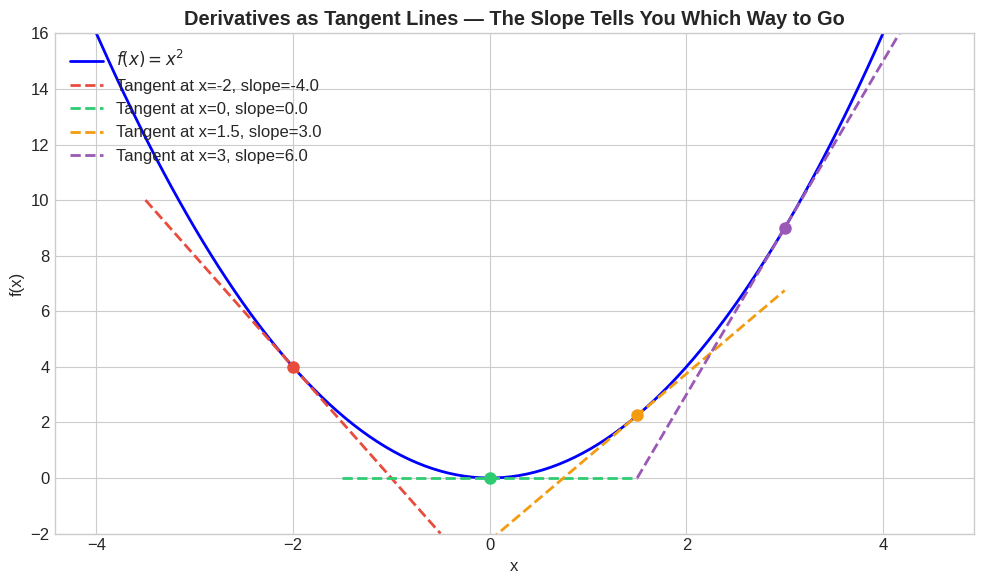

In [6]:
# visualize the derivative as the tangent line
x = np.linspace(-4, 4, 200)
y = x**2

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'b-', linewidth=2, label='$f(x) = x^2$')

# tangent lines at different points
points = [-2, 0, 1.5, 3]
colors = ['#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for x0, color in zip(points, colors):
    slope = 2 * x0
    tangent_x = np.linspace(x0 - 1.5, x0 + 1.5, 50)
    tangent_y = slope * (tangent_x - x0) + x0**2
    ax.plot(tangent_x, tangent_y, '--', color=color, linewidth=2,
            label=f"Tangent at x={x0}, slope={slope:.1f}")
    ax.plot(x0, x0**2, 'o', color=color, markersize=8, zorder=5)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Derivatives as Tangent Lines — The Slope Tells You Which Way to Go',
             fontweight='bold')
ax.set_ylim(-2, 16)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 5.2 Symbolic Differentiation with SymPy

SymPy lets us compute exact (symbolic) derivatives — useful for verifying intuition.

In [7]:
x_sym = sp.Symbol('x')

# common functions you'll see in AI
functions = {
    'x²': x_sym**2,
    'sin(x)': sp.sin(x_sym),
    'e^x': sp.exp(x_sym),
    'ln(x)': sp.ln(x_sym),
    'sigmoid σ(x)': 1 / (1 + sp.exp(-x_sym)),
    'ReLU approx': sp.log(1 + sp.exp(x_sym)),  # Softplus (smooth ReLU)
}

print("Function Derivatives (common in AI):")
print("=" * 60)
for name, f_sym in functions.items():
    deriv = sp.diff(f_sym, x_sym)
    deriv_simplified = sp.simplify(deriv)
    print(f"  f(x) = {name:20s} → f'(x) = {deriv_simplified}")

Function Derivatives (common in AI):
  f(x) = x²                   → f'(x) = 2*x
  f(x) = sin(x)               → f'(x) = cos(x)
  f(x) = e^x                  → f'(x) = exp(x)
  f(x) = ln(x)                → f'(x) = 1/x
  f(x) = sigmoid σ(x)         → f'(x) = 1/(4*cosh(x/2)**2)
  f(x) = ReLU approx          → f'(x) = exp(x)/(exp(x) + 1)


### 5.3 Partial Derivatives & Gradients

In AI, loss functions depend on **millions of parameters** — not just one variable. The gradient is the vector of all partial derivatives:

$$\nabla f(x_1, x_2, \dots, x_n) = \left( \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n} \right)$$

The gradient points in the direction of **steepest ascent**. To minimize loss, we go in the **opposite** direction.

In [8]:
# 2D loss function: f(w1, w2) = w1² + 2*w2² + w1*w2 - 4*w1 - 6*w2
def loss_2d(w1: float, w2: float) -> float:
    return w1**2 + 2*w2**2 + w1*w2 - 4*w1 - 6*w2

def grad_2d(w1: float, w2: float) -> tuple[float, float]:
    """Analytical gradient of the loss function."""
    df_dw1 = 2*w1 + w2 - 4       # ∂f/∂w1
    df_dw2 = 4*w2 + w1 - 6       # ∂f/∂w2
    return df_dw1, df_dw2

# Numerical gradient for verification
def numerical_gradient(f, w1, w2, h=1e-7):
    df_dw1 = (f(w1 + h, w2) - f(w1 - h, w2)) / (2 * h)
    df_dw2 = (f(w1, w2 + h) - f(w1, w2 - h)) / (2 * h)
    return df_dw1, df_dw2

# Verify at a point
w1, w2 = 1.0, 1.0
ana = grad_2d(w1, w2)
num = numerical_gradient(loss_2d, w1, w2)
print(f"At (w1, w2) = ({w1}, {w2}):")
print(f"  Analytical gradient: ({ana[0]:.6f}, {ana[1]:.6f})")
print(f"  Numerical gradient:  ({num[0]:.6f}, {num[1]:.6f})")
print(f"  Match: {np.allclose(ana, num)}")

At (w1, w2) = (1.0, 1.0):
  Analytical gradient: (-1.000000, -1.000000)
  Numerical gradient:  (-1.000000, -1.000000)
  Match: True


/tmp/ipykernel_2240/1902568848.py:42: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2240/1902568848.py:42: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


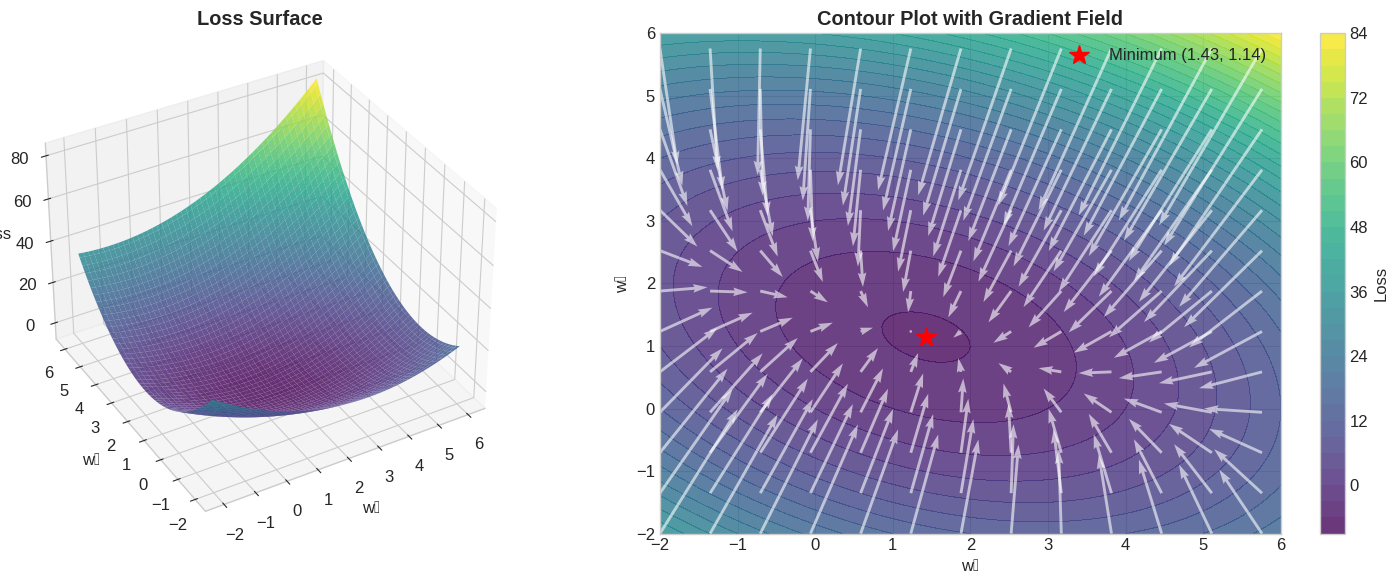

In [9]:
# visualize the loss surface and gradient field
w1_range = np.linspace(-2, 6, 100)
w2_range = np.linspace(-2, 6, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = loss_2d(W1, W2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3d surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(W1, W2, Z, cmap=cm.viridis, alpha=0.8, linewidth=0)
ax1.set_xlabel('w₁')
ax1.set_ylabel('w₂')
ax1.set_zlabel('Loss')
ax1.set_title('Loss Surface', fontweight='bold')
ax1.view_init(elev=35, azim=-120)
axes[0].remove()  # Remove the 2D axes placeholder

# contour plot with gradient arrows
ax2 = axes[1]
contour = ax2.contourf(W1, W2, Z, levels=30, cmap='viridis', alpha=0.8)
plt.colorbar(contour, ax=ax2, label='Loss')

# gradient field (subsampled)
skip = 8
w1_sub = W1[::skip, ::skip]
w2_sub = W2[::skip, ::skip]
g1, g2 = grad_2d(w1_sub, w2_sub)
# Negative gradient — direction of descent
ax2.quiver(w1_sub, w2_sub, -g1, -g2, color='white', alpha=0.6, scale=80)

# mark the minimum
# solve: 2w1 + w2 = 4, w1 + 4w2 = 6 → w1 = 10/7, w2 = 8/7
w1_min, w2_min = 10/7, 8/7
ax2.plot(w1_min, w2_min, 'r*', markersize=15, label=f'Minimum ({w1_min:.2f}, {w2_min:.2f})')

ax2.set_xlabel('w₁')
ax2.set_ylabel('w₂')
ax2.set_title('Contour Plot with Gradient Field', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

### 5.4 The Chain Rule — The Engine of Backpropagation

The chain rule is **the single most important calculus concept for AI**. It allows us to compute gradients through compositions of functions — which is exactly what a neural network is.

$$\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$$

A neural network with layers $l_1, l_2, l_3$:

$$\text{Loss} = L(l_3(l_2(l_1(x))))$$

$$\frac{\partial \text{Loss}}{\partial w_1} = \frac{\partial L}{\partial l_3} \cdot \frac{\partial l_3}{\partial l_2} \cdot \frac{\partial l_2}{\partial l_1} \cdot \frac{\partial l_1}{\partial w_1}$$

In [10]:
# Chain rule demonstration: backpropagation on a mini "network"
# Network: input x → multiply by w → apply sigmoid → compute MSE loss

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# Forward pass
x_input = 2.0
w = 0.5          # Weight we want to optimize
y_true = 0.8     # Target output

# Step 1: Linear transform
z = w * x_input                    # z = wx
# Step 2: Activation
a = sigmoid(z)                     # a = σ(z)
# Step 3: Loss (MSE)
loss = (a - y_true)**2             # L = (a - y)²

print("FORWARD PASS")
print(f"  x = {x_input}, w = {w}")
print(f"  z = w·x = {z}")
print(f"  a = σ(z) = {a:.6f}")
print(f"  Loss = (a - y)² = {loss:.6f}")

# Backward pass (chain rule!)
dL_da = 2 * (a - y_true)          # ∂L/∂a = 2(a - y)
da_dz = sigmoid_derivative(z)      # ∂a/∂z = σ'(z) = σ(z)(1-σ(z))
dz_dw = x_input                    # ∂z/∂w = x

# Chain rule: ∂L/∂w = ∂L/∂a · ∂a/∂z · ∂z/∂w
dL_dw = dL_da * da_dz * dz_dw

print("\nBACKWARD PASS (Chain Rule)")
print(f"  ∂L/∂a = 2(a - y) = {dL_da:.6f}")
print(f"  ∂a/∂z = σ'(z)    = {da_dz:.6f}")
print(f"  ∂z/∂w = x        = {dz_dw:.6f}")
print(f"  ∂L/∂w = ∂L/∂a · ∂a/∂z · ∂z/∂w = {dL_dw:.6f}")

# Verify with numerical gradient
h = 1e-7
loss_plus  = (sigmoid((w + h) * x_input) - y_true)**2
loss_minus = (sigmoid((w - h) * x_input) - y_true)**2
numerical_grad = (loss_plus - loss_minus) / (2 * h)
print(f"\n  Numerical check:  {numerical_grad:.6f}")
print(f"  Match: {np.isclose(dL_dw, numerical_grad)}")

FORWARD PASS
  x = 2.0, w = 0.5
  z = w·x = 1.0
  a = σ(z) = 0.731059
  Loss = (a - y)² = 0.004753

BACKWARD PASS (Chain Rule)
  ∂L/∂a = 2(a - y) = -0.137883
  ∂a/∂z = σ'(z)    = 0.196612
  ∂z/∂w = x        = 2.000000
  ∂L/∂w = ∂L/∂a · ∂a/∂z · ∂z/∂w = -0.054219

  Numerical check:  -0.054219
  Match: True


### 5.5 Gradient Descent from Scratch

The gradient descent update rule:

$$\theta_{t+1} = \theta_t - \alpha \nabla L(\theta_t)$$

Where $\alpha$ is the **learning rate** — the single most important hyperparameter.

In [11]:
def gradient_descent_2d(
    loss_fn,
    grad_fn,
    w1_init: float,
    w2_init: float,
    lr: float = 0.1,
    n_steps: int = 50,
) -> dict:
    """Run gradient descent on a 2D loss function."""
    w1, w2 = w1_init, w2_init
    history = {'w1': [w1], 'w2': [w2], 'loss': [loss_fn(w1, w2)]}

    for step in range(n_steps):
        g1, g2 = grad_fn(w1, w2)
        w1 -= lr * g1
        w2 -= lr * g2
        history['w1'].append(w1)
        history['w2'].append(w2)
        history['loss'].append(loss_fn(w1, w2))

    return history

# Run gradient descent from (5, 5)
history = gradient_descent_2d(loss_2d, grad_2d, w1_init=5.0, w2_init=5.0, lr=0.1, n_steps=40)

print(f"Start:  w1={history['w1'][0]:.4f}, w2={history['w2'][0]:.4f}, loss={history['loss'][0]:.4f}")
print(f"End:    w1={history['w1'][-1]:.4f}, w2={history['w2'][-1]:.4f}, loss={history['loss'][-1]:.4f}")
print(f"Target: w1={10/7:.4f}, w2={8/7:.4f}")

Start:  w1=5.0000, w2=5.0000, loss=50.0000
End:    w1=1.4303, w2=1.1422, loss=-6.2857
Target: w1=1.4286, w2=1.1429


/tmp/ipykernel_2240/2812854031.py:24: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2240/2812854031.py:24: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()


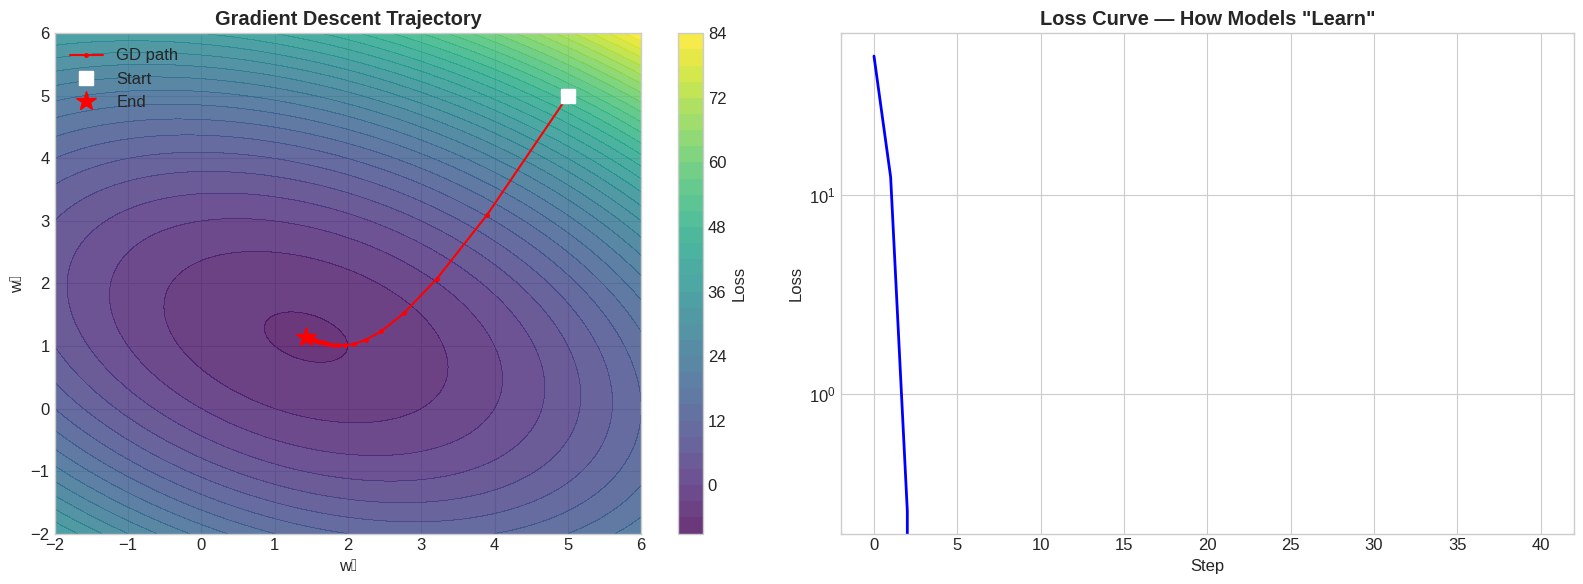

In [12]:
# visualize the optimization trajectory
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# contour plot with trajectory
ax1 = axes[0]
contour = ax1.contourf(W1, W2, Z, levels=30, cmap='viridis', alpha=0.8)
plt.colorbar(contour, ax=ax1, label='Loss')
ax1.plot(history['w1'], history['w2'], 'r.-', linewidth=1.5, markersize=5, label='GD path')
ax1.plot(history['w1'][0], history['w2'][0], 'ws', markersize=10, label='Start')
ax1.plot(history['w1'][-1], history['w2'][-1], 'r*', markersize=15, label='End')
ax1.set_xlabel('w₁')
ax1.set_ylabel('w₂')
ax1.set_title('Gradient Descent Trajectory', fontweight='bold')
ax1.legend()

# loss curve
ax2 = axes[1]
ax2.plot(history['loss'], 'b-', linewidth=2)
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss')
ax2.set_title('Loss Curve — How Models "Learn"', fontweight='bold')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

### 5.6 Learning Rate — The Most Critical Hyperparameter

- **Too small** → converges very slowly
- **Too large** → oscillates or diverges
- **Just right** → smooth, fast convergence

/tmp/ipykernel_2240/2756018128.py:28: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2240/2756018128.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()


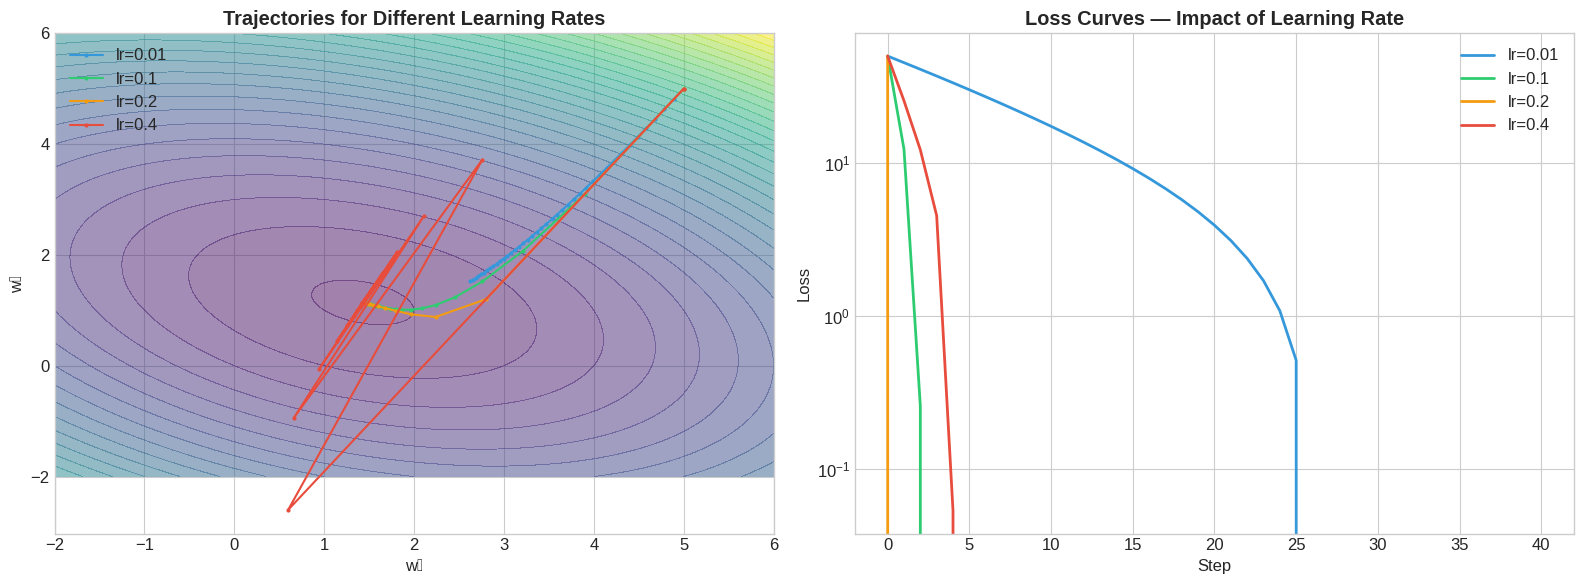

In [ ]:
# compare different learning rates
learning_rates = [0.01, 0.1, 0.2, 0.4]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for lr, color in zip(learning_rates, colors):
    h = gradient_descent_2d(loss_2d, grad_2d, 5.0, 5.0, lr=lr, n_steps=40)

    # trajectory
    axes[0].plot(h['w1'], h['w2'], '.-', color=color, linewidth=1.5, markersize=4, label=f'lr={lr}')
    # loss curve
    axes[1].plot(h['loss'], '-', color=color, linewidth=2, label=f'lr={lr}')

# background contour
axes[0].contourf(W1, W2, Z, levels=30, cmap='viridis', alpha=0.5)
axes[0].set_xlabel('w₁')
axes[0].set_ylabel('w₂')
axes[0].set_title('Trajectories for Different Learning Rates', fontweight='bold')
axes[0].legend()

axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Curves — Impact of Learning Rate', fontweight='bold')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### 5.7 Activation Functions & Their Derivatives

Activation functions introduce non-linearity. Their derivatives determine how gradients flow during backpropagation.

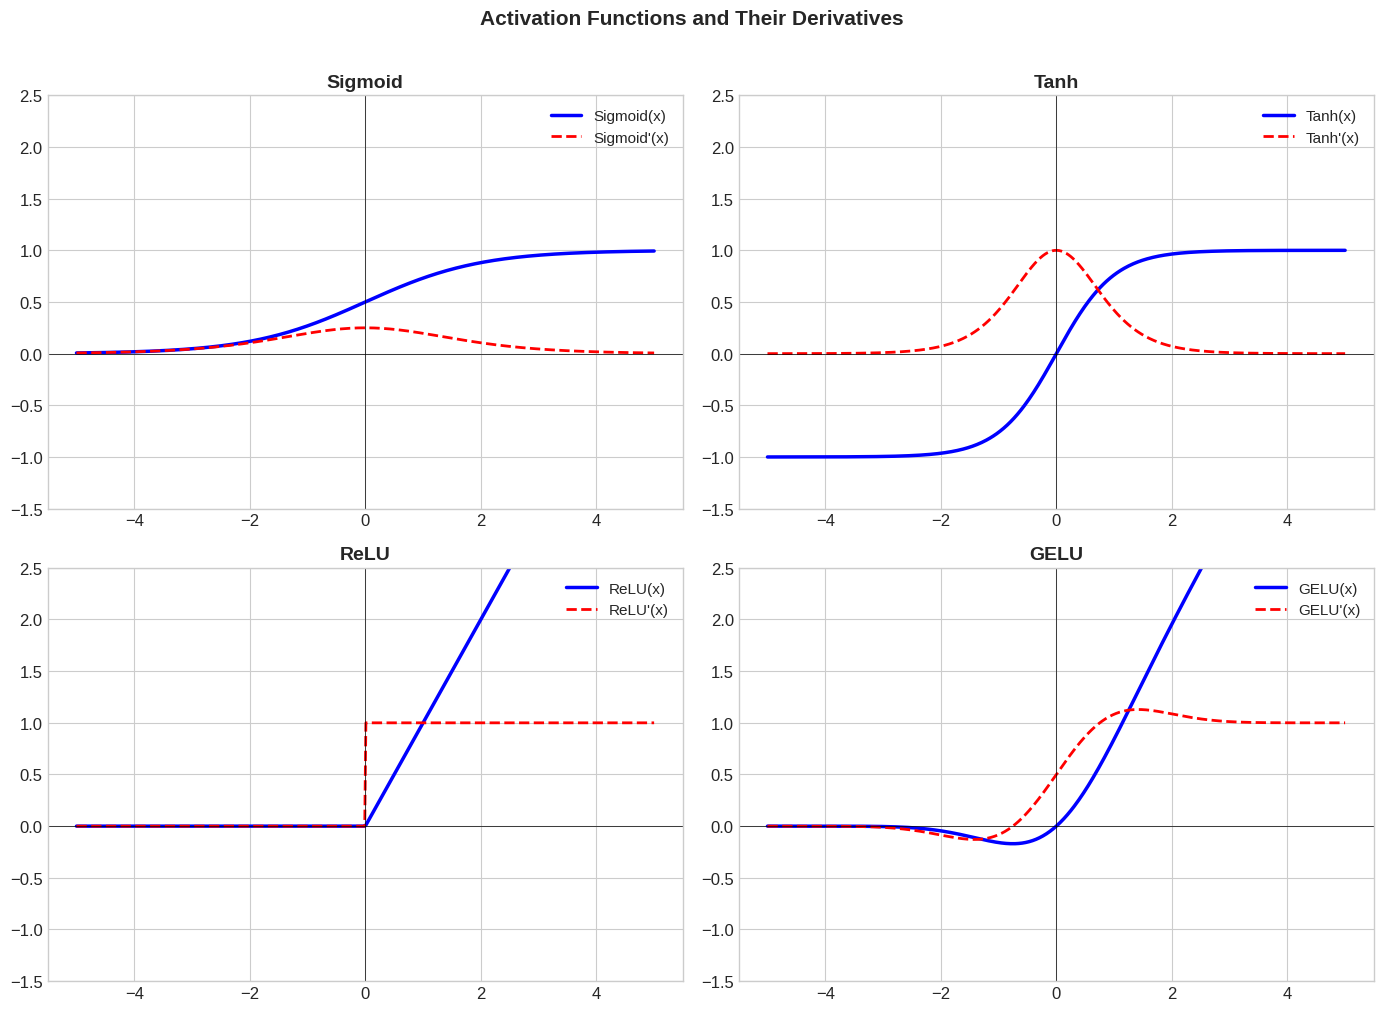

Key observations:
  • Sigmoid/Tanh derivatives → 0 for large |x| → vanishing gradient problem
  • ReLU derivative is 0 for x < 0 → dead neurons problem
  • GELU (used in modern LLMs) has smooth gradients everywhere


In [ ]:
x = np.linspace(-5, 5, 500)

activations = {
    'Sigmoid': (sigmoid(x), sigmoid(x) * (1 - sigmoid(x))),
    'Tanh': (np.tanh(x), 1 - np.tanh(x)**2),
    'ReLU': (np.maximum(0, x), (x > 0).astype(float)),
    'GELU': (
        0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3))),
        None  # We'll compute numerically
    ),
}

# numerical derivative for GELU
gelu = lambda z: 0.5 * z * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))
activations['GELU'] = (activations['GELU'][0], np.gradient(gelu(x), x))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, (func_vals, deriv_vals)) in zip(axes.flat, activations.items()):
    ax.plot(x, func_vals, 'b-', linewidth=2.5, label=f'{name}(x)')
    ax.plot(x, deriv_vals, 'r--', linewidth=2, label=f"{name}'(x)")
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_title(name, fontweight='bold', fontsize=14)
    ax.legend(fontsize=11)
    ax.set_ylim(-1.5, 2.5)

plt.suptitle('Activation Functions and Their Derivatives',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  • Sigmoid/Tanh derivatives → 0 for large |x| → vanishing gradient problem")
print("  • ReLU derivative is 0 for x < 0 → dead neurons problem")
print("  • GELU (used in modern LLMs) has smooth gradients everywhere")

## 7. Evaluation — Linear Regression via Gradient Descent

Let's train a linear regression model from scratch using only calculus.

In [ ]:
# generate synthetic data: y = 3x + 7 + noise
np.random.seed(RANDOM_SEED)
n_samples = 100
X_data = np.random.uniform(-5, 5, n_samples)
y_data = 3.0 * X_data + 7.0 + np.random.randn(n_samples) * 1.5

# initialize parameters randomly
w = np.random.randn()  # slope
b = np.random.randn()  # intercept
lr = 0.01
n_epochs = 100

loss_history = []

for epoch in range(n_epochs):
    # forward pass: predictions
    y_pred = w * X_data + b

    # loss: MSE = (1/N) Σ(y_pred - y_true)²
    loss = np.mean((y_pred - y_data)**2)
    loss_history.append(loss)

    # gradients (from calculus)
    dL_dw = (2 / n_samples) * np.sum((y_pred - y_data) * X_data)
    dL_db = (2 / n_samples) * np.sum(y_pred - y_data)

    # update
    w -= lr * dL_dw
    b -= lr * dL_db

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}: loss={loss:.4f}, w={w:.4f}, b={b:.4f}")

print(f"\nFinal: w={w:.4f} (true: 3.0), b={b:.4f} (true: 7.0)")

Epoch   0: loss=98.0792, w=0.4966, b=1.5466
Epoch  20: loss=15.9430, w=2.7458, b=3.2802
Epoch  40: loss=8.1582, w=2.8360, b=4.4967
Epoch  60: loss=4.6683, w=2.8679, b=5.3137
Epoch  80: loss=3.0984, w=2.8887, b=5.8617

Final: w=2.9021 (true: 3.0), b=6.2142 (true: 7.0)


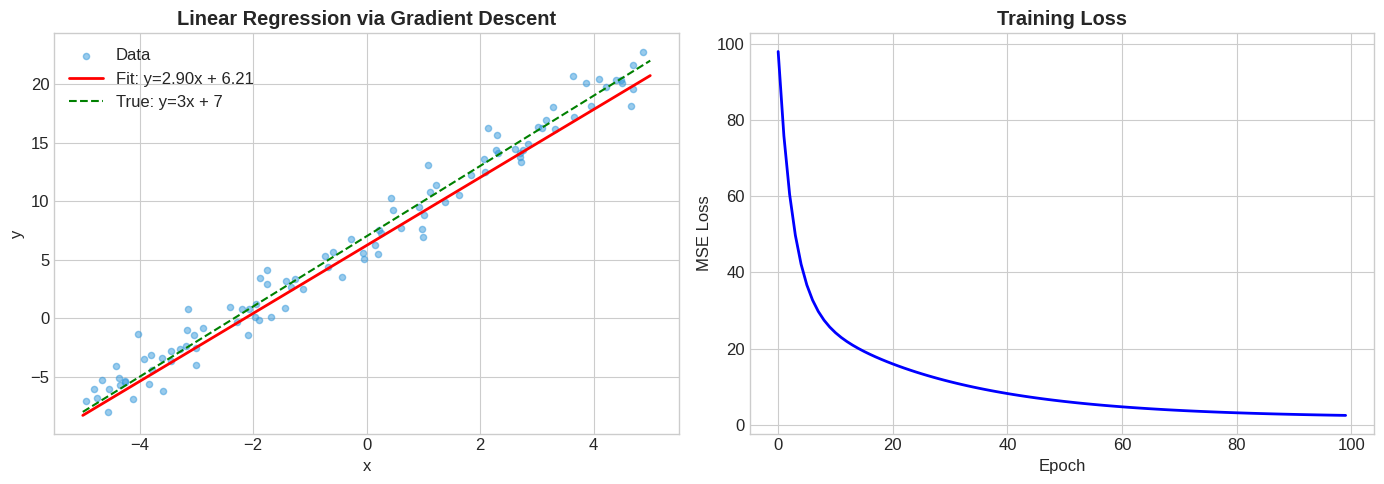

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# data + fitted line
axes[0].scatter(X_data, y_data, alpha=0.5, s=20, color='#3498db', label='Data')
x_line = np.linspace(-5, 5, 100)
axes[0].plot(x_line, w * x_line + b, 'r-', linewidth=2, label=f'Fit: y={w:.2f}x + {b:.2f}')
axes[0].plot(x_line, 3 * x_line + 7, 'g--', linewidth=1.5, label='True: y=3x + 7')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Linear Regression via Gradient Descent', fontweight='bold')
axes[0].legend()

# loss curve
axes[1].plot(loss_history, 'b-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Training Loss', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Exercises

### Exercise 1: Derivative Warm-up
Use SymPy to compute the derivatives of:
- $f(x) = x^3 - 2x^2 + 5x - 3$
- $f(x) = \frac{1}{1 + e^{-2x}}$ (sigmoid with slope 2)
- $f(x) = \ln(x^2 + 1)$

In [17]:
# Exercise 1
x_s = sp.Symbol('x')

exercises = [
    x_s**3 - 2*x_s**2 + 5*x_s - 3,
    1 / (1 + sp.exp(-2*x_s)),
    sp.ln(x_s**2 + 1),
]

for f_sym in exercises:
    deriv = sp.simplify(sp.diff(f_sym, x_s))
    print(f"f(x) = {f_sym}")
    print(f"f'(x) = {deriv}\n")

f(x) = x**3 - 2*x**2 + 5*x - 3
f'(x) = 3*x**2 - 4*x + 5

f(x) = 1/(1 + exp(-2*x))
f'(x) = 1/(2*cosh(x)**2)

f(x) = log(x**2 + 1)
f'(x) = 2*x/(x**2 + 1)



### Exercise 2: Implement Polynomial Regression
Extend the linear regression above to fit $y = ax^2 + bx + c$ using gradient descent.

Learned: y = 0.528x² + (-1.986)x + 0.890
True:    y = 0.500x² + (-2.000)x + 1.000


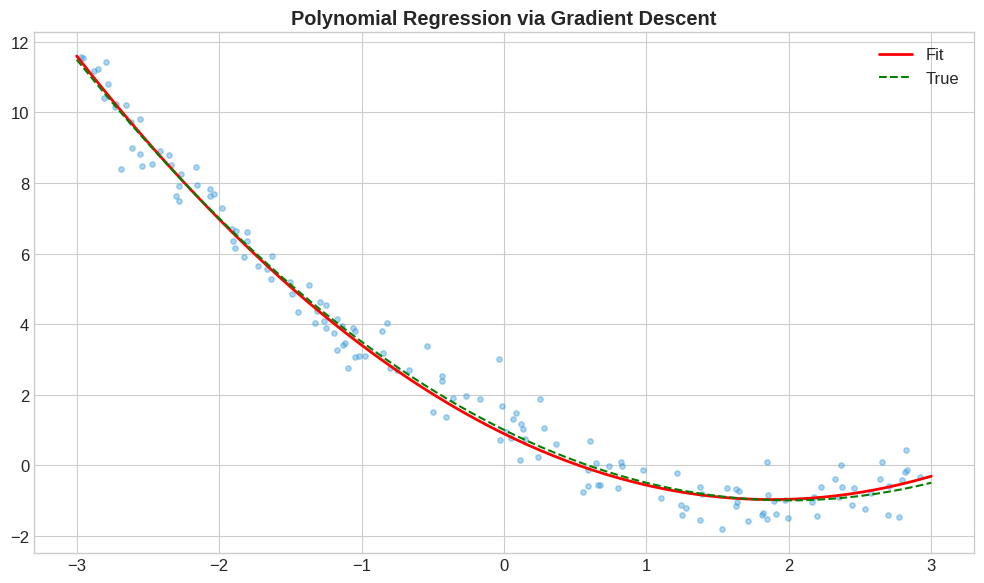

In [18]:
# Exercise 2 — Polynomial regression from scratch
np.random.seed(42)
X_poly = np.random.uniform(-3, 3, 150)
y_poly = 0.5 * X_poly**2 - 2 * X_poly + 1 + np.random.randn(150) * 0.5

# Initialize coefficients
a, b_coef, c = 0.0, 0.0, 0.0
lr = 0.005

for epoch in range(500):
    y_pred = a * X_poly**2 + b_coef * X_poly + c
    loss = np.mean((y_pred - y_poly)**2)
    N = len(X_poly)

    da = (2/N) * np.sum((y_pred - y_poly) * X_poly**2)
    db = (2/N) * np.sum((y_pred - y_poly) * X_poly)
    dc = (2/N) * np.sum(y_pred - y_poly)

    a -= lr * da
    b_coef -= lr * db
    c -= lr * dc

print(f"Learned: y = {a:.3f}x² + ({b_coef:.3f})x + {c:.3f}")
print(f"True:    y = 0.500x² + (-2.000)x + 1.000")

x_plot = np.linspace(-3, 3, 200)
plt.scatter(X_poly, y_poly, alpha=0.4, s=15, color='#3498db')
plt.plot(x_plot, a*x_plot**2 + b_coef*x_plot + c, 'r-', lw=2, label='Fit')
plt.plot(x_plot, 0.5*x_plot**2 - 2*x_plot + 1, 'g--', lw=1.5, label='True')
plt.legend()
plt.title('Polynomial Regression via Gradient Descent', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Challenge Problems

### Challenge 1: Implement Momentum
Modify gradient descent to include momentum: $v_t = \beta v_{t-1} + \nabla L$, then $\theta_t = \theta_{t-1} - \alpha v_t$.
Compare convergence with and without momentum on the 2D loss surface.

### Challenge 2: Gradient Descent on Rosenbrock
Try gradient descent on the Rosenbrock function $f(x,y) = (1-x)^2 + 100(y-x^2)^2$. Observe how hard it is for plain GD — this is why advanced optimizers (Adam) matter.

### Challenge 3: Vanishing Gradients
Build a 10-layer chain of sigmoid activations. Compute how the gradient magnitude decreases at each layer (multiply sigmoid derivatives). Plot the result and explain why ReLU/GELU solved this.

## 10. Further Reading

| Resource | Type | Description |
|----------|------|-------------|
| [3Blue1Brown — Essence of Calculus](https://www.youtube.com/playlist?list=PLZHQObOWTQDMsr9K-rj53DwVRMYO3t5Yr) | 🎥 Video | Beautiful visual introduction to calculus |
| [3Blue1Brown — Gradient Descent](https://www.youtube.com/watch?v=IHZwWFHWa-w) | 🎥 Video | How neural networks learn |
| [Stanford CS231n — Backpropagation](https://cs231n.github.io/optimization-2/) | 📖 Notes | Detailed backprop walkthrough |
| [Mathematics for ML — Ch. 5](https://mml-book.github.io/) | 📘 Book | Vector calculus for optimization |

---

**Next:** [03 — Probability & Statistics →](03-probability-statistics.ipynb)